# Exploration of Supporting Vector Machine model

## Notebook structure

In [2]:
# 1. IMPORT LIBRARIES
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Sklearn utilities
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
project_path = '/content/drive/MyDrive/Fake News Project/'
#os.makedirs(project_path, exist_ok=True)

## Dataset

In [5]:

# 2. LOAD DATASET

# Load datasets
train_df = pd.read_csv("/content/drive/MyDrive/Fake News Project/data/training_data.csv", delimiter = "\t", header = None)
test_df = pd.read_csv("/content/drive/MyDrive/Fake News Project/data/testing_data.csv" , delimiter = "\t", header = None)


In [6]:
# DISPLAY BASIC INFORMATION

print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)


# Display first 5 rows
train_df.head()

Training Dataset Shape: (34152, 2)
Testing Dataset Shape: (9984, 2)


,0,1
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...


In [7]:
# Renamed the columns as label and text
train_df.columns = ['label', 'text']
test_df.columns = ['label', 'text']
train_df
test_df

,label,text
0,2,copycat muslim terrorist arrested with assault...
1,2,wow! chicago protester caught on camera admits...
2,2,germany's fdp look to fill schaeuble's big shoes
3,2,mi school sends welcome back packet warning ki...
4,2,u.n. seeks 'massive' aid boost amid rohingya '...
...,...,...
9979,2,boom! fox news leftist chris wallace attempts ...
9980,2,here it is: list of democrat hypocrites who vo...
9981,2,new fires ravage rohingya villages in northwes...
9982,2,meals on wheels shuts the lyin‚ lefties up wit...


## EDA

In [8]:
# 3. EXPLORATORY DATA ANALYSIS (EDA)


# CHECK DATASET INFO


print("\nTraining Dataset Info:\n")
train_df.info()


Training Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34152 entries, 0 to 34151
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   34152 non-null  int64 
 1   text    34152 non-null  object
dtypes: int64(1), object(1)
memory usage: 533.8+ KB


In [9]:
# CHECK MISSING VALUES


print("\nMissing Values in Training Dataset:\n")
print(train_df.isnull().sum())


print("\nMissing Values in Testing Dataset:\n")
print(test_df.isnull().sum())


Missing Values in Training Dataset:

label    0
text     0
dtype: int64

Missing Values in Testing Dataset:

label    0
text     0
dtype: int64


In [10]:
# CHECK DUPLICATES


print("\nDuplicate Rows in Training Dataset:", train_df.duplicated().sum())
print("Duplicate Rows in Testing Dataset:", test_df.duplicated().sum())


Duplicate Rows in Training Dataset: 1946
Duplicate Rows in Testing Dataset: 775


In [11]:
train_df['text'].duplicated().sum()


np.int64(1946)

In [12]:
test_df['text'].duplicated().sum()

np.int64(776)

In [13]:
train_df[train_df['text'].duplicated()]

,label,text
1534,0,mcconnell says he‚ll obstruct any effort to hi...
3054,0,no
4047,0,trump freaks out
4963,0,as trump collapses
5141,0,no
...,...,...
34047,1,u.s. has lost trust in south sudan\ttrump envo...
34049,1,u.s. house passes sanctions on iran-backed hez...
34054,1,trump declines to say if he will visit korean ...
34126,1,thailand kicks off sumptuous funeral of king b...


In [14]:
train_df[train_df['text'].duplicated(keep = False)]

,label,text
678,0,thanks to trump
986,0,no
1487,0,mcconnell says he‚ll obstruct any effort to hi...
1534,0,mcconnell says he‚ll obstruct any effort to hi...
1619,0,trump freaks out
...,...,...
34049,1,u.s. house passes sanctions on iran-backed hez...
34053,1,thailand kicks off sumptuous funeral of king b...
34054,1,trump declines to say if he will visit korean ...
34126,1,thailand kicks off sumptuous funeral of king b...


In [15]:
# REMOVE DUPLICATES (OPTIONAL)


train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

print("\nShape After Removing Duplicates:")
print("Training:", train_df.shape)
print("Testing:", test_df.shape)



Shape After Removing Duplicates:
Training: (32206, 2)
Testing: (9209, 2)


## DATA CLEANING

In [16]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [17]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [18]:
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove punctuation
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    # tokenize
    words = text.split()

    # remove stopwords + lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [19]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

## APPLY PREPROCESSING

In [20]:
train_df['text'] = train_df['text'].apply(clean_text)

In [21]:
test_df['text'] = test_df['text'].apply(clean_text)

In [22]:
train_df.head()
test_df.head()

,label,text
0,2,copycat muslim terrorist arrested assault weapon
1,2,wow chicago protester caught camera admits vio...
2,2,germany fdp look fill schaeuble big shoe
3,2,mi school sends welcome back packet warning ki...
4,2,u n seek massive aid boost amid rohingya emerg...


## Plots of most frequent words

In [35]:
train_df_plot=train_df.copy()
train_df_plot["text"]=train_df_plot["text"].apply(lambda x: x.split())
train_df_plot

,label,text
0,0,"[donald, trump, sends, embarrassing, new, year..."
1,0,"[drunk, bragging, trump, staffer, started, rus..."
2,0,"[sheriff, david, clarke, becomes, internet, jo..."
3,0,"[trump, obsessed, even, obama‚s, name, coded, ..."
4,0,"[pope, francis, called, donald, trump, christm..."
...,...,...
34147,1,"[tear, rain, thai, gather, late, king, funeral]"
34148,1,"[pyongyang, university, need, non, u, teacher,..."
34149,1,"[philippine, president, duterte, visit, japan,..."
34150,1,"[japan, abe, may, election, many, want, pm]"


In [36]:
from collections import Counter

tf_fake = Counter(
    word
    for sentence in train_df_plot.loc[train_df_plot["label"] == 0, "text"]
    for word in sentence
)

top_words_fake = tf_fake.most_common(10)

words_fake = [word for word, count in top_words_fake]
counts_fake = [count for word, count in top_words_fake]

In [37]:
from collections import Counter

tf_real = Counter(
    word
    for sentence in train_df_plot.loc[train_df_plot["label"] == 1, "text"]
    for word in sentence
)

top_words_real = tf_real.most_common(10)

words_real = [word for word, count in top_words_real]
counts_real = [count for word, count in top_words_real]

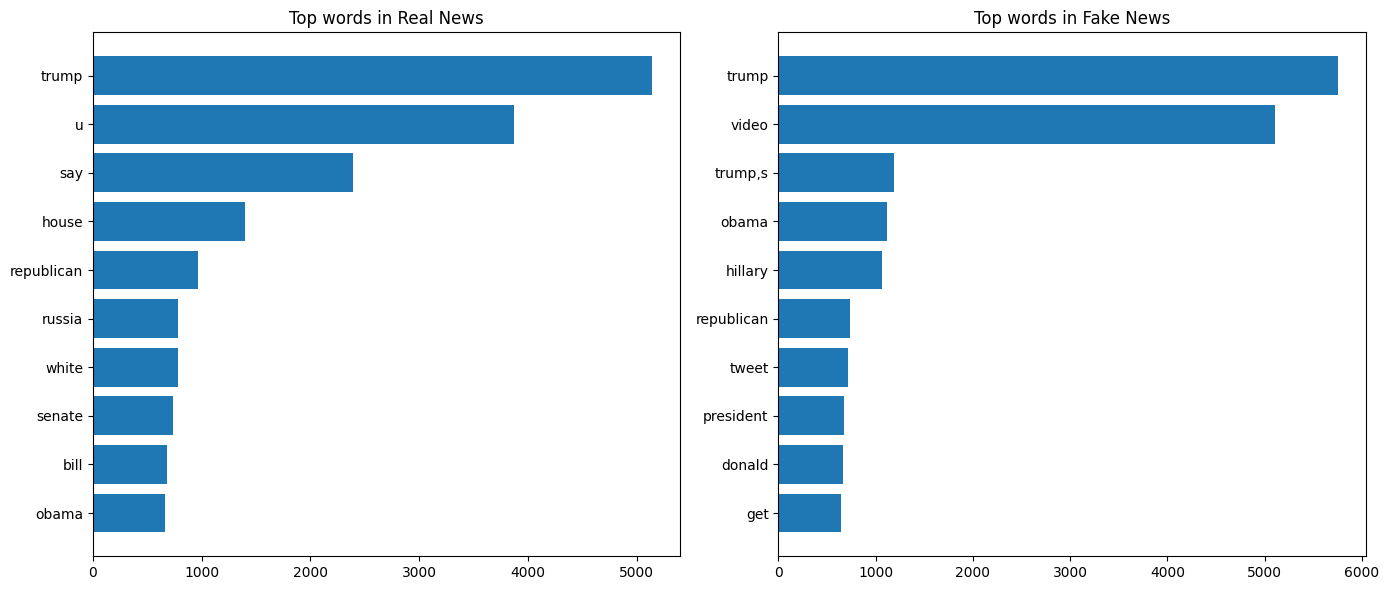

In [38]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Real news
axes[0].barh(words_real, counts_real)
axes[0].set_title("Top words in Real News")
axes[0].invert_yaxis()

# Fake news
axes[1].barh(words_fake, counts_fake)
axes[1].set_title("Top words in Fake News")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [39]:
#Fake counts
fake_bigram_counts = Counter()

for sentence in train_df_plot.loc[train_df["label"] == 0, "text"]:

    fake_bigrams = zip(sentence[:-1], sentence[1:])

    fake_bigram_counts.update(fake_bigrams)

print(fake_bigram_counts.most_common(10))
top_fake_bigrams = fake_bigram_counts.most_common(10)

fake_bilabels = [" ".join(bigram) for bigram, count in top_fake_bigrams]

fake_bicounts = [count for bigram, count in top_fake_bigrams]

[(('donald', 'trump'), 547), (('trump', 'supporter'), 270), (('fox', 'news'), 232), (('hillary', 'clinton'), 216), (('white', 'house'), 213), (('president', 'trump'), 211), (('trump', 'video'), 182), (('‚', 'video'), 178), (('ted', 'cruz'), 177), (('bernie', 'sander'), 162)]


In [40]:
#real counts
real_bigram_counts = Counter()

for sentence in train_df_plot.loc[train_df["label"] == 1, "text"]:

    real_bigrams = zip(sentence[:-1], sentence[1:])

    real_bigram_counts.update(real_bigrams)

print(real_bigram_counts.most_common(10))
top_real_bigrams = real_bigram_counts.most_common(10)

real_bilabels = [" ".join(bigram) for bigram, count in top_real_bigrams]

real_bicounts = [count for bigram, count in top_real_bigrams]

[(('white', 'house'), 755), (('north', 'korea'), 386), (('trump', 'say'), 324), (('u', 'n'), 305), (('supreme', 'court'), 213), (('u', 'house'), 158), (('u', 'senate'), 153), (('travel', 'ban'), 147), (('puerto', 'rico'), 147), (('say', 'u'), 145)]


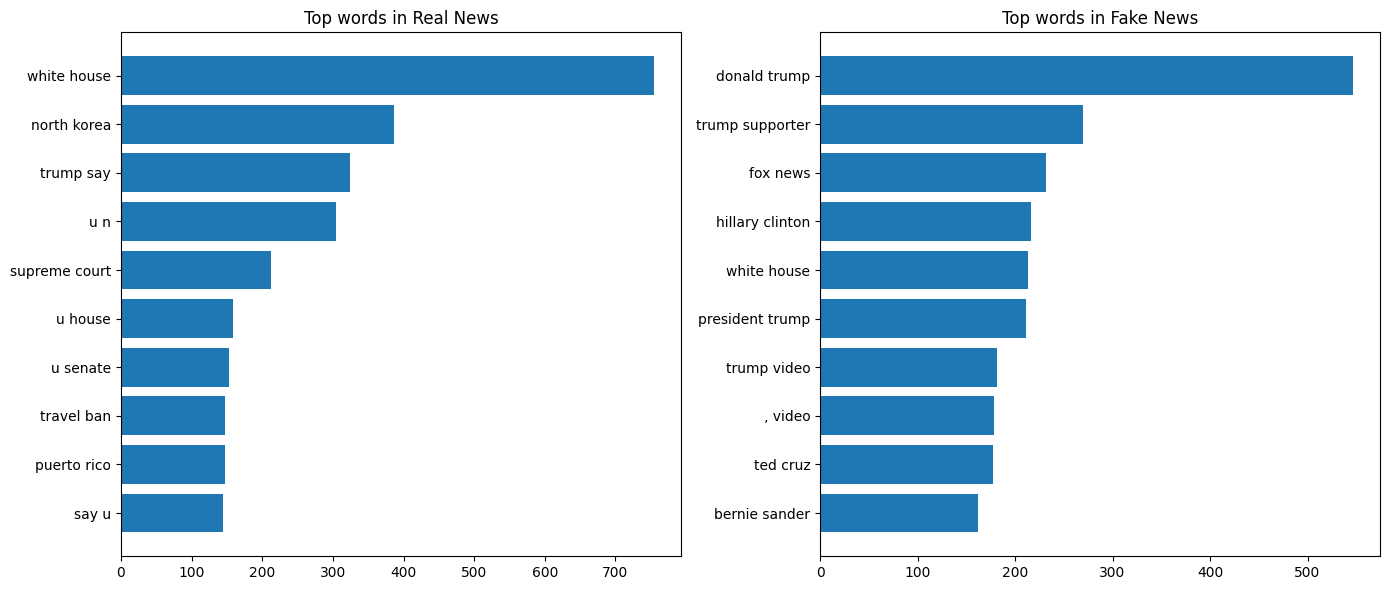

In [41]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Real news
axes[0].barh(real_bilabels, real_bicounts)
axes[0].set_title("Top words in Real News")
axes[0].invert_yaxis()

# Fake news
axes[1].barh(fake_bilabels, fake_bicounts)
axes[1].set_title("Top words in Fake News")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## TRAIN-TEST SPLIT

In [42]:
from sklearn.model_selection import train_test_split

train_df_train, train_df_val = train_test_split(train_df, test_size = 0.2, random_state = 42, stratify = train_df['label'])

In [43]:
train_df_train

,label,text
25297,1,clinton think regulator scrutinize time warner...
453,0,suspicious smoke billowing closing russian con...
885,0,trump jr ‚s latest move prof russia investigat...
11091,0,flashback video show leftist medium member pra...
5134,0,nevertrump gopers demand emergency rnc meeting...
...,...,...
20703,1,house speaker optimistic tax reform prospect y...
31238,1,exclusive colleague name putin daughter withdr...
5751,0,trump scotland collapse united kingdom great g...
18314,1,house panel drop effort force testimony trump ...


## Bag of Words-vectorization

In [44]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer =  CountVectorizer()

train_df_train_bow = vectorizer.fit_transform(train_df_train['text'])
train_df_val_bow = vectorizer.transform(train_df_val['text'])

# Print shape of vectorized dataset
print("Training BOW Shape:", train_df_train_bow.shape)
print("Validation BOW Shape:", train_df_val_bow.shape)

### then we continue on our classifier of choice

Training BOW Shape: (25764, 15165)
Validation BOW Shape: (6442, 15165)


## TF-IDF vectorization

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(   tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    token_pattern=None)

# Vectorize all dataset
train_df_train_tfidf = vectorizer.fit_transform(train_df_train['text'])
train_df_val_tfidf = vectorizer.transform(train_df_val['text'])

# Print shape of vectorized dataset
print("Training TF-IDF Shape:", train_df_train_tfidf.shape)
print("Validation TF-IDF Shape:", train_df_val_tfidf.shape)

### then we continue on our classifier of choice

Training TF-IDF Shape: (25764, 49)
Validation TF-IDF Shape: (6442, 49)


# Classifier: Supporting Vector Machine




*   Uses a subset of training points that are the support vectors
*   Different kernel functions to support decisions.




In [ ]:
from sklearn.svm import SVC

## Bag of words. Vectorized

In [ ]:
modelBoW = SVC()
modelBoW.fit(train_df_train_bow, train_df_train["label"])

SVC()

In [ ]:
val_pred_BoW = modelBoW.predict(train_df_val_bow) #On the validation data with bag of words


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
matrix_BoW=confusion_matrix(train_df_val['label'],val_pred_BoW)
print(matrix_BoW)
score=accuracy_score(train_df_val['label'],val_pred_BoW)
print(score)
report=classification_report(train_df_val['label'],val_pred_BoW)
print(report)

[[2907  298]
 [ 141 3096]]
0.9318534616578702
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      3205
           1       0.91      0.96      0.93      3237

    accuracy                           0.93      6442
   macro avg       0.93      0.93      0.93      6442
weighted avg       0.93      0.93      0.93      6442



<Axes: >

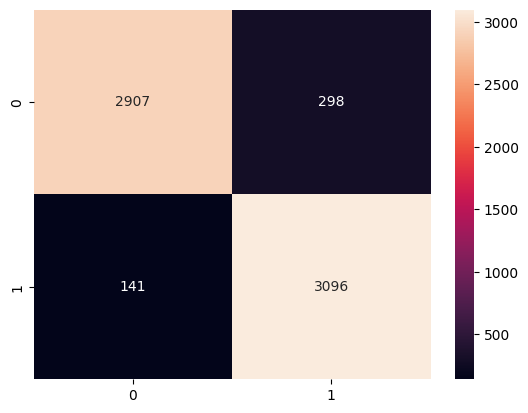

In [ ]:
import seaborn as sns
sns.heatmap(matrix_BoW, annot=True, fmt='d')

## Model with TF-IDF vectors

In [ ]:
model_TFIDF = SVC()
model_TFIDF.fit(train_df_train_tfidf, train_df_train["label"])

SVC()

In [ ]:
val_pred_TFIDF = model_TFIDF.predict(train_df_val_tfidf) #On the validation data with bag of words

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
matrix_TFIDF=confusion_matrix(train_df_val['label'],val_pred_TFIDF)
print(matrix_TFIDF)
scorev0=accuracy_score(train_df_val['label'],val_pred_TFIDF)
print(scorev0)
scorev0=accuracy_score(train_df_val['label'],val_pred_TFIDF)
print(scorev0)
reportv0=classification_report(train_df_val['label'],val_pred_TFIDF)
print(report)

[[2200 1005]
 [ 169 3068]]
0.8177584601055573
0.8177584601055573
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      3205
           1       0.92      0.93      0.92      3237

    accuracy                           0.92      6442
   macro avg       0.92      0.92      0.92      6442
weighted avg       0.92      0.92      0.92      6442



<Axes: title={'center': 'TFIDF'}>

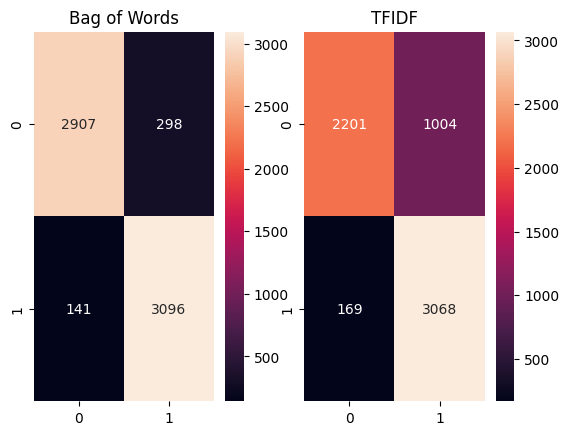

In [ ]:
#Plotting the confusion matrix for each
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=1, ncols=2)
sns.heatmap(matrix_BoW, annot=True, fmt='d', ax = ax[0])
ax[0].set_title("Bag of Words")
ax[1].set_title("TFIDF")
sns.heatmap(matrix_TFIDF, annot=True, fmt='d', ax = ax[1])

## Conclusion:
- Considering that this dataset set is balanced, the accuracy would have indicated the BoW was the best model. The TF-IDF does not show good results but in this notebook I will explore the use of TF-IDF because the exploration of BoW (in the copied notebook) did not showed good results in metrics like recall, which is very important for this dataset. (better to have false positives than false negatives).

## Tuning parameters of the vectorizer.

Focusing on:
- n_grams
- max_df
- min_df

So far we used the default, which is:
* ngram= unigram, (1,1)
* max_df = 1
  This ignore terms that have a high frequency throughout documents
* min_df = 1
  this ignores terms with low frequency.

## Model v1: n_grams to uni and bi grams

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer2 = TfidfVectorizer(ngram_range= (1,2))

# Vectorize all dataset
X_train_unibigram_TFIDF = vectorizer2.fit_transform(train_df_train['text'])
X_val_unibigram_TFIDF = vectorizer2.transform(train_df_val['text'])

#Performing the model
model_TFIDF_v1 = SVC()
model_TFIDF_v1.fit(X_train_unibigram_TFIDF, train_df_train["label"])


SVC()

In [ ]:
val_pred_TFIDF_v1 = model_TFIDF_v1.predict(X_val_unibigram_TFIDF) #On the validation data with bag of words


from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
matrix_TFIDF_v1=confusion_matrix(train_df_val['label'],val_pred_TFIDF_v1)
print(matrix_TFIDF_v1)
scorev1=accuracy_score(train_df_val['label'],val_pred_TFIDF_v1)
print(score)
report=classification_report(train_df_val['label'],val_pred_TFIDF_v1)
print(report)

[[2951  254]
 [ 163 3074]]
0.9318534616578702
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      3205
           1       0.92      0.95      0.94      3237

    accuracy                           0.94      6442
   macro avg       0.94      0.94      0.94      6442
weighted avg       0.94      0.94      0.94      6442



## Model V2. onlybigrams


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer3 = TfidfVectorizer(ngram_range= (2,2))

# Vectorize all dataset
X_train_bi_TFIDF = vectorizer3.fit_transform(train_df_train['text'])
X_val_bi_TFIDF = vectorizer3.transform(train_df_val['text'])

#Performing the model
model_TFIDF_v2=SVC()
model_TFIDF_v2.fit(X_train_bi_TFIDF, train_df_train["label"])

SVC()

In [ ]:
val_pred_TFIDF_v2 = model_TFIDF_v2.predict(X_val_bi_TFIDF) #On the validation data with bag of words


matrix_TFIDF_v2=confusion_matrix(train_df_val['label'],val_pred_TFIDF_v2)
print(matrix_TFIDF_v2)
score=accuracy_score(train_df_val['label'],val_pred_TFIDF_v2)
print(score)
report=classification_report(train_df_val['label'],val_pred_TFIDF_v2)
print(report)

[[2840  365]
 [ 485 2752]]
0.8680533995653523
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      3205
           1       0.88      0.85      0.87      3237

    accuracy                           0.87      6442
   macro avg       0.87      0.87      0.87      6442
weighted avg       0.87      0.87      0.87      6442



## Model v3: Max df to 80% in unibi

In [ ]:
vectorizer4 = TfidfVectorizer(ngram_range= (1,2), max_df=0.8)

# Vectorize all dataset
X_train_unibi80_TFIDF = vectorizer4.fit_transform(train_df_train['text'])
X_val_unibi80_TFIDF = vectorizer4.transform(train_df_val['text'])

#Performing the model
model_TFIDF_v3=SVC()
model_TFIDF_v3.fit(X_train_unibi80_TFIDF, train_df_train["label"])

SVC()

In [ ]:
val_pred_TFIDF_v3 = model_TFIDF_v3.predict(X_val_unibi80_TFIDF) #On the validation data with bag of words


matrix_TFIDF_v3=confusion_matrix(train_df_val['label'],val_pred_TFIDF_v3)
print(matrix_TFIDF_v3)
score=accuracy_score(train_df_val['label'],val_pred_TFIDF_v3)
print(score)
report=classification_report(train_df_val['label'],val_pred_TFIDF_v3)
print(report)

[[2951  254]
 [ 163 3074]]
0.9352685501397081
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      3205
           1       0.92      0.95      0.94      3237

    accuracy                           0.94      6442
   macro avg       0.94      0.94      0.94      6442
weighted avg       0.94      0.94      0.94      6442



## Model v4: min_df to 3

In [ ]:
vectorizer5 = TfidfVectorizer(ngram_range= (1,2), min_df=3)

# Vectorize all dataset
X_train_unibimin3_TFIDF = vectorizer5.fit_transform(train_df_train['text'])
X_val_unibimin3_TFIDF = vectorizer5.transform(train_df_val['text'])

#Performing the model
model_TFIDF_v4=SVC()
model_TFIDF_v4.fit(X_train_unibimin3_TFIDF, train_df_train["label"])

SVC()

In [ ]:
val_pred_TFIDF_v4 = model_TFIDF_v4.predict(X_val_unibimin3_TFIDF) #On the validation data with bag of words


matrix_TFIDF_v4=confusion_matrix(train_df_val['label'],val_pred_TFIDF_v4)
print(matrix_TFIDF_v4)
score=accuracy_score(train_df_val['label'],val_pred_TFIDF_v4)
print(score)
report=classification_report(train_df_val['label'],val_pred_TFIDF_v4)
print(report)

[[2941  264]
 [ 151 3086]]
0.9355790127289662
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      3205
           1       0.92      0.95      0.94      3237

    accuracy                           0.94      6442
   macro avg       0.94      0.94      0.94      6442
weighted avg       0.94      0.94      0.94      6442



## Model v5: Add normalization l1

In [ ]:
vectorizer6 = TfidfVectorizer(ngram_range= (1,2), min_df=3, norm="l1")

# Vectorize all dataset
X_train_unibimin3l1_TFIDF = vectorizer6.fit_transform(train_df_train['text'])
X_val_unibimin3l1_TFIDF = vectorizer6.transform(train_df_val['text'])

#Performing the model
model_TFIDF_v5=SVC()
model_TFIDF_v5.fit(X_train_unibimin3l1_TFIDF, train_df_train["label"])

SVC()

In [ ]:
val_pred_TFIDF_v5 = model_TFIDF_v5.predict(X_val_unibimin3l1_TFIDF) #On the validation data with bag of words


matrix_TFIDF_v5=confusion_matrix(train_df_val['label'],val_pred_TFIDF_v5)
print(matrix_TFIDF_v5)
score=accuracy_score(train_df_val['label'],val_pred_TFIDF_v5)
print(score)
report=classification_report(train_df_val['label'],val_pred_TFIDF_v5)
print(report)

[[2866  339]
 [ 121 3116]]
0.9285936044706613
              precision    recall  f1-score   support

           0       0.96      0.89      0.93      3205
           1       0.90      0.96      0.93      3237

    accuracy                           0.93      6442
   macro avg       0.93      0.93      0.93      6442
weighted avg       0.93      0.93      0.93      6442



## Model v6. unitrigrams


In [ ]:
vectorizer7 = TfidfVectorizer(ngram_range= (1,3), min_df=3)

# Vectorize all dataset
X_train_unitrimin3_TFIDF = vectorizer7.fit_transform(train_df_train['text'])
X_val_unitrimin3_TFIDF = vectorizer7.transform(train_df_val['text'])

#Performing the model
model_TFIDF_v6=SVC()
model_TFIDF_v6.fit(X_train_unitrimin3_TFIDF, train_df_train["label"])

SVC()

In [ ]:
val_pred_TFIDF_v6 = model_TFIDF_v6.predict(X_val_unitrimin3_TFIDF) #On the validation data with bag of words


matrix_TFIDF_v6=confusion_matrix(train_df_val['label'],val_pred_TFIDF_v6)
print(matrix_TFIDF_v6)
score=accuracy_score(train_df_val['label'],val_pred_TFIDF_v6)
print(score)
report=classification_report(train_df_val['label'],val_pred_TFIDF_v6)
print(report)

[[2941  264]
 [ 155 3082]]
0.9349580875504502
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      3205
           1       0.92      0.95      0.94      3237

    accuracy                           0.93      6442
   macro avg       0.94      0.93      0.93      6442
weighted avg       0.94      0.93      0.93      6442



Not much difference, but this increases the data size so keeping uni and bi.

## Conclusion:

This explorations did not induced significant improvements in the model. The best performance was obtained with ngram_range= (1,2), min_df=3. Maximum recall reach was 0.92 in most of them. So hyperparameter tuning is needed.

## Hyperparameter fine tuning

In [ ]:
SVC().get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [ ]:
#C: Sets the amount of regularization, small is for strong regularization
# gamma: is the coefficient for the kernel.

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score

In [ ]:
# Set up possible values of parameters to optimize over
param_grid = {'C': [ 1, 10, 100],
			'gamma': [1, 0.1, 0.001],
			'kernel': ['rbf','linear']}
grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3, scoring ="f1")
grid.fit(X_train_unibimin3l1_TFIDF, train_df_train["label"])

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV 1/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.927 total time=  36.4s
[CV 2/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.935 total time=  36.6s
[CV 3/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.931 total time=  36.9s
[CV 4/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.927 total time=  36.6s
[CV 5/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.934 total time=  36.7s


KeyboardInterrupt: 

## Best parameters:
for SVC: C=10, gamma=1, Kernel=linear

##Fine tuned model

In [ ]:
#Performing the model
model_TFIDF_fine=SVC(C=10, gamma=1, kernel='linear')
model_TFIDF_fine.fit(X_train_unibimin3_TFIDF, train_df_train["label"])

SVC(C=10, gamma=1, kernel='linear')

In [ ]:
val_pred_TFIDF_fine = model_TFIDF_fine.predict(X_val_unibimin3_TFIDF) #On the validation data with bag of words


matrix_TFIDF_fine=confusion_matrix(train_df_val['label'],val_pred_TFIDF_fine)
print(matrix_TFIDF_fine)
score=accuracy_score(train_df_val['label'],val_pred_TFIDF_fine)
print(score)
report=classification_report(train_df_val['label'],val_pred_TFIDF_fine)
print(report)

[[2929  276]
 [ 218 3019]]
0.9233157404532754
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      3205
           1       0.92      0.93      0.92      3237

    accuracy                           0.92      6442
   macro avg       0.92      0.92      0.92      6442
weighted avg       0.92      0.92      0.92      6442



## Conclusion : Results are balanced but no increase in recall.

## Embedding

## QWEN!

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
model_embed = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

In [ ]:
#Substitutes the vectorizer function for the training set
train_embeddings = model_embed.encode(
    train_df_train['text'].tolist(),
    #batch_size=32,
    show_progress_bar=True
)

Batches:   0%|          | 0/806 [00:00<?, ?it/s]

In [ ]:
#Substitutes the vectorizer function for the validation set
val_embeddings = model_embed.encode(
    train_df_val['text'].tolist(),
    #batch_size=32,
    show_progress_bar=True
)

Batches:   0%|          | 0/202 [00:00<?, ?it/s]

In [ ]:
#Performing the model
model_qwen3_fine=SVC(C=10, gamma=1, kernel='linear')
model_qwen3_fine.fit(train_embeddings, train_df_train["label"])

SVC(C=10, gamma=1, kernel='linear')

In [ ]:
val_pred_qwen3_fine = model_qwen3_fine.predict(val_embeddings)

matrix_qwen3_fine=confusion_matrix(train_df_val['label'],val_pred_qwen3_fine)
print(matrix_qwen3_fine)
scoreqwen3=accuracy_score(train_df_val['label'],val_pred_qwen3_fine)
print(scoreqwen3)
report=classification_report(train_df_val['label'],val_pred_qwen3_fine)
print(report)

[[2907  298]
 [ 240 2997]]
0.9164855634895995
              precision    recall  f1-score   support

           0       0.92      0.91      0.92      3205
           1       0.91      0.93      0.92      3237

    accuracy                           0.92      6442
   macro avg       0.92      0.92      0.92      6442
weighted avg       0.92      0.92      0.92      6442



##BGE

In [ ]:
modelbge2 = SentenceTransformer("BAAI/bge-small-en-v1.5")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
#Substitutes the vectorizer function for the training set
train_emb_bge = modelbge2.encode(
    train_df_train['text'].tolist(),
    #batch_size=32,
    show_progress_bar=True
)
#Substitutes the vectorizer function for the validation set
val_emb_bge = modelbge2.encode(
    train_df_val['text'].tolist(),
    #batch_size=32,
    show_progress_bar=True
)

Batches:   0%|          | 0/806 [00:00<?, ?it/s]

Batches:   0%|          | 0/202 [00:00<?, ?it/s]

In [ ]:
#Performing the model
model_bge_fine=SVC(C=10, gamma=1, kernel='linear')
model_bge_fine.fit(train_emb_bge, train_df_train["label"])

SVC(C=10, gamma=1, kernel='linear')

In [ ]:
val_pred_bge_fine = model_bge_fine.predict(val_emb_bge)

matrix_bge_fine=confusion_matrix(train_df_val['label'],val_pred_bge_fine)
print(matrix_bge_fine)
scorebge=accuracy_score(train_df_val['label'],val_pred_bge_fine)
print(scorebge)
report=classification_report(train_df_val['label'],val_pred_bge_fine)
print(report)

[[2912  293]
 [ 240 2997]]
0.9172617199627445
              precision    recall  f1-score   support

           0       0.92      0.91      0.92      3205
           1       0.91      0.93      0.92      3237

    accuracy                           0.92      6442
   macro avg       0.92      0.92      0.92      6442
weighted avg       0.92      0.92      0.92      6442



## Summary

In [ ]:
#Must collect all F1 scores and recall scores in one table to compare iterations

### Initial BoW or TFIDF

In [ ]:
from sklearn.metrics import recall_score, f1_score
#modelv0BoW
from sklearn.metrics import recall_score, f1_score
#modelv0BoW
step1_dict=[
{
    "model":"Modelv0BoW",
    "f1score": f1_score(train_df_val['label'],val_pred_BoW),
    "recallscore": recall_score(train_df_val['label'],val_pred_BoW)
},

{
    "model": "modelv0TFIDF",
    "f1score" : f1_score(train_df_val['label'],val_pred_TFIDF),
    "recallscore" : recall_score(train_df_val['label'],val_pred_TFIDF)
}
             ]

step1_df = pd.DataFrame(step1_dict)
step1_df

,model,f1score,recallscore
0,Modelv0BoW,0.933796,0.956441
1,modelv0TFIDF,0.839513,0.947791


### TFIDF Exploration of vectorizer parameters

In [ ]:
#modelv0BoW
step2_list=[
{"model":"TFIDF-unibigram",
"f1score": f1_score(train_df_val['label'],val_pred_TFIDF_v1),
"recallscore": recall_score(train_df_val['label'],val_pred_TFIDF_v1)},

{"model": "TFIDF-bigram",
"f1score" : f1_score(train_df_val['label'],val_pred_TFIDF_v2),
"recallscore" : recall_score(train_df_val['label'],val_pred_TFIDF_v2)},

{"model": "TFIDF-unibimaxdf80",
"f1score" : f1_score(train_df_val['label'],val_pred_TFIDF_v3),
"recallscore" : recall_score(train_df_val['label'],val_pred_TFIDF_v3)},

{"model": "TFIDF-unibimindf3",
"f1score" : f1_score(train_df_val['label'],val_pred_TFIDF_v4),
"recallscore" : recall_score(train_df_val['label'],val_pred_TFIDF_v4)},

{"model": "TFIDF-unibil1",
"f1score" : f1_score(train_df_val['label'],val_pred_TFIDF_v5),
"recallscore" : recall_score(train_df_val['label'],val_pred_TFIDF_v5)},

{"model": "TFIDF-unitrimindf3",
"f1score" : f1_score(train_df_val['label'],val_pred_TFIDF_v6),
"recallscore" : recall_score(train_df_val['label'],val_pred_TFIDF_v6)},

]
step2_df = pd.DataFrame(step2_list)
step2_df.round(3)

,model,f1score,recallscore
0,TFIDF-unibigram,0.936,0.950
1,TFIDF-bigram,0.866,0.850
2,TFIDF-unibimaxdf80,0.936,0.950
3,TFIDF-unibimindf3,0.937,0.953
4,TFIDF-unibil1,0.931,0.963
5,TFIDF-unitrimindf3,0.936,0.952


### Fine tuned model SVC

In [ ]:
step3_dict = [
{"model": "TFIDF-unibimindf3",
"f1score" : f1_score(train_df_val['label'],val_pred_TFIDF_v4),
"recallscore" : recall_score(train_df_val['label'],val_pred_TFIDF_v4)},

{"model": "TFIDF-unibimindf3_finetuned",
"f1score" : f1_score(train_df_val['label'],val_pred_TFIDF_fine),
"recallscore" : recall_score(train_df_val['label'],val_pred_TFIDF_fine)},

 {
     "model": "TFIDF-unibimindf3_qwen3",
    "f1score" : f1_score(train_df_val['label'],val_pred_qwen3_fine),
    "recallscore" : recall_score(train_df_val['label'],val_pred_qwen3_fine)},

{
    "model": "TFIDF-embed BGE",
    "f1score" : f1_score(train_df_val['label'],val_pred_bge_fine),
    "recallscore" : recall_score(train_df_val['label'],val_pred_bge_fine)},

               {
    "model": "TFIDF-FinetunedBert",
    "f1score" : 0.96,
    "recallscore" : 0.94 }

]
step3_df = pd.DataFrame(step3_dict)
step3_df.round(3)


,model,f1score,recallscore
0,TFIDF-unibimindf3,0.937,0.953
1,TFIDF-unibimindf3_finetuned,0.924,0.933
2,TFIDF-unibimindf3_qwen3,0.918,0.926
3,TFIDF-embed BGE,0.918,0.926


In [ ]:
All_steps = pd.concat([step2_df,step3_df])
All_steps.round(3)

,model,f1score,recallscore
0,TFIDF-unibigram,0.936,0.950
1,TFIDF-bigram,0.866,0.850
2,TFIDF-unibimaxdf80,0.936,0.950
3,TFIDF-unibimindf3,0.937,0.953
4,TFIDF-unibil1,0.931,0.963
5,TFIDF-unitrimindf3,0.936,0.952
0,TFIDF-unibimindf3,0.937,0.953
1,TFIDF-unibimindf3_finetuned,0.924,0.933
2,TFIDF-unibimindf3_qwen3,0.918,0.926
3,TFIDF-embed BGE,0.918,0.926


## Attempt to use fine tuned models from Hugging face

In [23]:
from transformers import pipeline
model_roberta = "winterForestStump/Roberta-fake-news-detector"
clf = pipeline("text-classification", model=model_roberta, tokenizer=model_roberta)


config.json:   0%|          | 0.00/859 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: winterForestStump/Roberta-fake-news-detector
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/957 [00:00<?, ?B/s]

In [24]:
print(clf.model.config.id2label)

{0: 'FAKE', 1: 'TRUE'}


In [25]:
# I need to give this model only the lists of sentences.
train_pred_roberta= clf(
    train_df["text"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    truncation=True
)

In [26]:
train_pred_roberta_labels = [pred["label"] for pred in train_pred_roberta]
type(train_pred_roberta_labels)

list

In [27]:
mapping = {"FAKE": 0, "TRUE": 1}
train_pred_roberta_numeric = [mapping[label] for label in train_pred_roberta_labels]

In [28]:
print("Accuracy:", accuracy_score(train_df["label"], train_pred_roberta_numeric))
print("F1:", f1_score(train_df["label"], train_pred_roberta_numeric))
print("Recall:", recall_score(train_df["label"], train_pred_roberta_numeric))

print(classification_report(train_df["label"], train_pred_roberta_numeric))

NameError: name 'accuracy_score' is not defined

In [29]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import Dataset, DatasetDict

model = AutoModelForSequenceClassification.from_pretrained("winterForestStump/Roberta-fake-news-detector")
tokenizer = AutoTokenizer.from_pretrained("winterForestStump/Roberta-fake-news-detector")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: winterForestStump/Roberta-fake-news-detector
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [47]:
dataset = DatasetDict({
    "train": Dataset.from_pandas((train_df_train[['text', 'label']]), preserve_index=False, ),
    "test": Dataset.from_pandas(( train_df_val[['text', 'label']]), preserve_index=False,)})

In [48]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25764
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 6442
    })
})

In [49]:
def tokenize_dataset(dataset):
    return tokenizer(dataset["text"])
dataset = dataset.map(tokenize_dataset, batched=True)


Map:   0%|          | 0/25764 [00:00<?, ? examples/s]

Map:   0%|          | 0/6442 [00:00<?, ? examples/s]

In [50]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


In [51]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=f"{project_path}/model_HF",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    push_to_hub=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

In [52]:
from transformers import Trainer

trainer =Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer,
    data_collator=data_collator,

)

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.187931,0.164387
2,0.126284,0.163785


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=6442, training_loss=0.17950647715935977, metrics={'train_runtime': 421.8112, 'train_samples_per_second': 122.159, 'train_steps_per_second': 15.272, 'total_flos': 622387145898960.0, 'train_loss': 0.17950647715935977, 'epoch': 2.0})

In [53]:
trainer.save_model(f"{project_path}/model_HF")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [54]:
tokenizer.save_pretrained(f"{project_path}/model_HF")

('/content/drive/MyDrive/Fake News Project//model_HF/tokenizer_config.json',
 '/content/drive/MyDrive/Fake News Project//model_HF/tokenizer.json')

In [55]:
val_test_pred = trainer.predict(dataset["test"])
preds = val_test_pred.predictions.argmax(axis=1)
true_labels = val_test_pred.label_ids


In [56]:
from sklearn.metrics import classification_report
print(classification_report(true_labels,preds))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      3205
           1       0.96      0.97      0.97      3237

    accuracy                           0.97      6442
   macro avg       0.97      0.97      0.97      6442
weighted avg       0.97      0.97      0.97      6442



In [82]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(true_labels,preds)
acc

0.9660043464762497

In [57]:
train_df_val["predicted"] = preds


In [67]:
val_df_plotfinal=train_df_val.copy()
val_df_plotfinal["text"]=val_df_plotfinal["text"].apply(lambda x: x.split())



In [68]:
#Fake counts
fake_bigram_val_counts = Counter()

for sentence in val_df_plotfinal.loc[val_df_plotfinal["predicted"] == 0, "text"]:

    fake_bigrams_val = zip(sentence[:-1], sentence[1:])

    fake_bigram_val_counts.update(fake_bigrams_val)

print(fake_bigram_val_counts.most_common(10))
top_fake_bigrams_val = fake_bigram_val_counts.most_common(10)

fake_bilabels_val = [" ".join(bigram) for bigram, count in top_fake_bigrams_val]

fake_bicounts_val = [count for bigram, count in top_fake_bigrams_val]

[(('donald', 'trump'), 123), (('trump', 'supporter'), 51), (('president', 'trump'), 49), (('ted', 'cruz'), 44), (('white', 'house'), 40), (('hillary', 'clinton'), 37), (('‚', 'video'), 35), (('bernie', 'sander'), 32), (('fox', 'news'), 31), (('trump', 'video'), 30)]


In [69]:
#real counts
real_bigram_counts_val = Counter()

for sentence in val_df_plotfinal.loc[val_df_plotfinal["predicted"] == 1, "text"]:

    real_bigrams_val = zip(sentence[:-1], sentence[1:])

    real_bigram_counts_val.update(real_bigrams_val)

print(real_bigram_counts_val.most_common(10))
top_real_bigrams_val = real_bigram_counts_val.most_common(10)

real_bilabels_val = [" ".join(bigram) for bigram, count in top_real_bigrams_val]

real_bicounts_val = [count for bigram, count in top_real_bigrams_val]

[(('white', 'house'), 154), (('trump', 'say'), 77), (('north', 'korea'), 74), (('u', 'n'), 65), (('supreme', 'court'), 42), (('puerto', 'rico'), 41), (('say', 'u'), 38), (('say', 'trump'), 36), (('u', 'senate'), 32), (('u', 'house'), 31)]


In [70]:
#Fake counts in original validation set
fake_bigram_val_counts2 = Counter()

for sentence in val_df_plotfinal.loc[val_df_plotfinal["label"] == 0, "text"]:

    fake_bigrams_val2 = zip(sentence[:-1], sentence[1:])

    fake_bigram_val_counts2.update(fake_bigrams_val2)

print(fake_bigram_val_counts2.most_common(10))
top_fake_bigrams_val2 = fake_bigram_val_counts2.most_common(10)

fake_bilabels_val2 = [" ".join(bigram) for bigram, count in top_fake_bigrams_val2]

fake_bicounts_val2 = [count for bigram, count in top_fake_bigrams_val2]

[(('donald', 'trump'), 116), (('trump', 'supporter'), 52), (('president', 'trump'), 50), (('ted', 'cruz'), 44), (('white', 'house'), 41), (('‚', 'video'), 35), (('hillary', 'clinton'), 35), (('bernie', 'sander'), 32), (('fox', 'news'), 31), (('trump', 'video'), 30)]


In [71]:
#real counts
real_bigram_counts_val2 = Counter()

for sentence in val_df_plotfinal.loc[val_df_plotfinal["label"] == 1, "text"]:

    real_bigrams_val2 = zip(sentence[:-1], sentence[1:])

    real_bigram_counts_val2.update(real_bigrams_val2)

print(real_bigram_counts_val2.most_common(10))
top_real_bigrams_val2 = real_bigram_counts_val2.most_common(10)

real_bilabels_val2 = [" ".join(bigram) for bigram, count in top_real_bigrams_val2]

real_bicounts_val2 = [count for bigram, count in top_real_bigrams_val2]

[(('white', 'house'), 153), (('trump', 'say'), 77), (('north', 'korea'), 73), (('u', 'n'), 64), (('supreme', 'court'), 43), (('puerto', 'rico'), 42), (('say', 'u'), 38), (('say', 'trump'), 36), (('u', 'senate'), 32), (('u', 'house'), 32)]


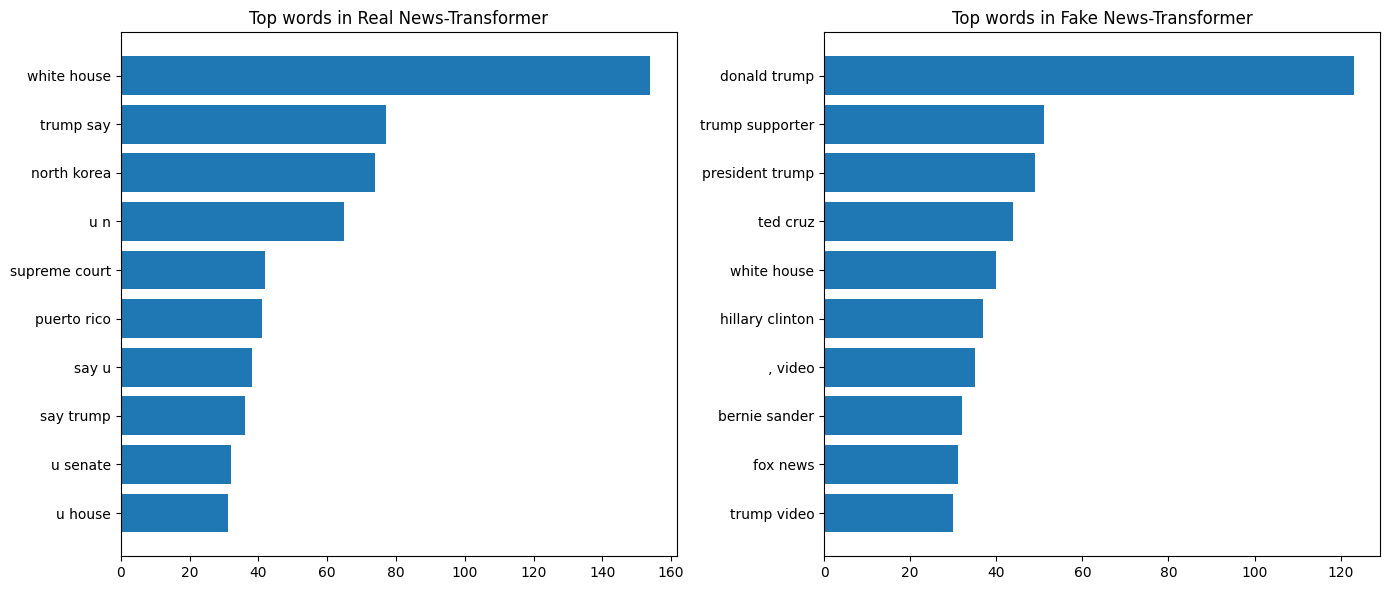

In [72]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Real news
axes[0].barh(real_bilabels_val, real_bicounts_val)
axes[0].set_title("Top words in Real News-Transformer")
axes[0].invert_yaxis()

# Fake news
axes[1].barh(fake_bilabels_val, fake_bicounts_val)
axes[1].set_title("Top words in Fake News-Transformer")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()



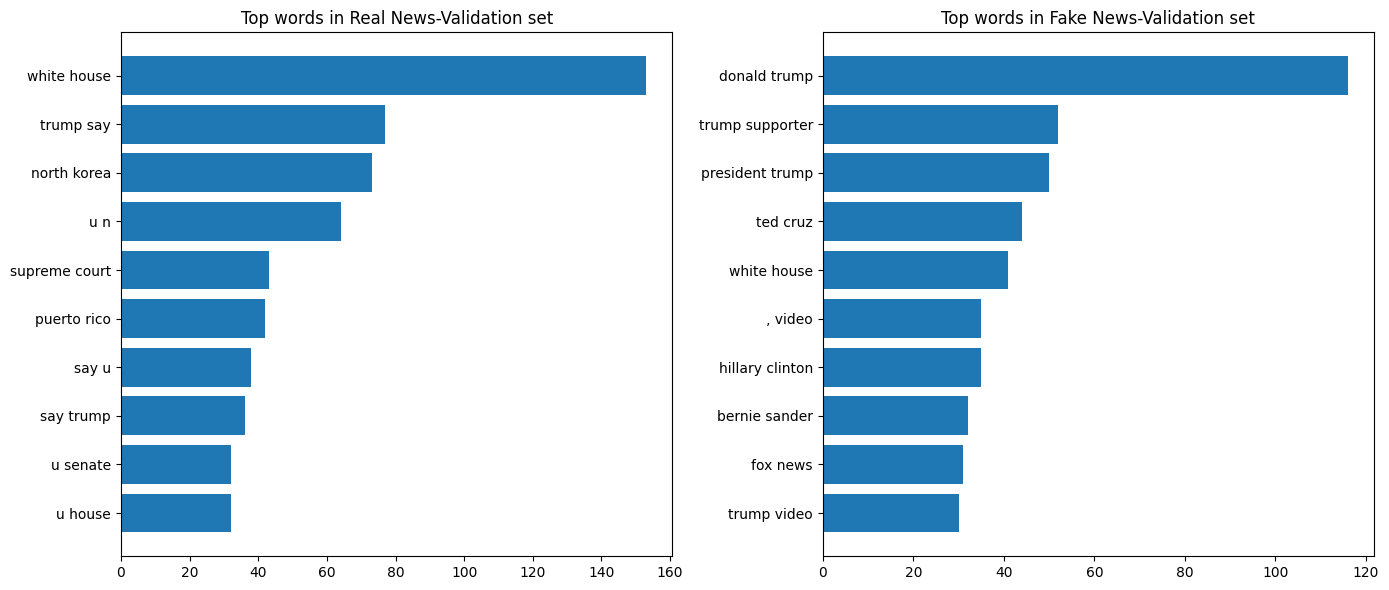

In [73]:

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Real news
axes[0].barh(real_bilabels_val2, real_bicounts_val2)
axes[0].set_title("Top words in Real News-Validation set")
axes[0].invert_yaxis()

# Fake news
axes[1].barh(fake_bilabels_val2, fake_bicounts_val2)
axes[1].set_title("Top words in Fake News-Validation set")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

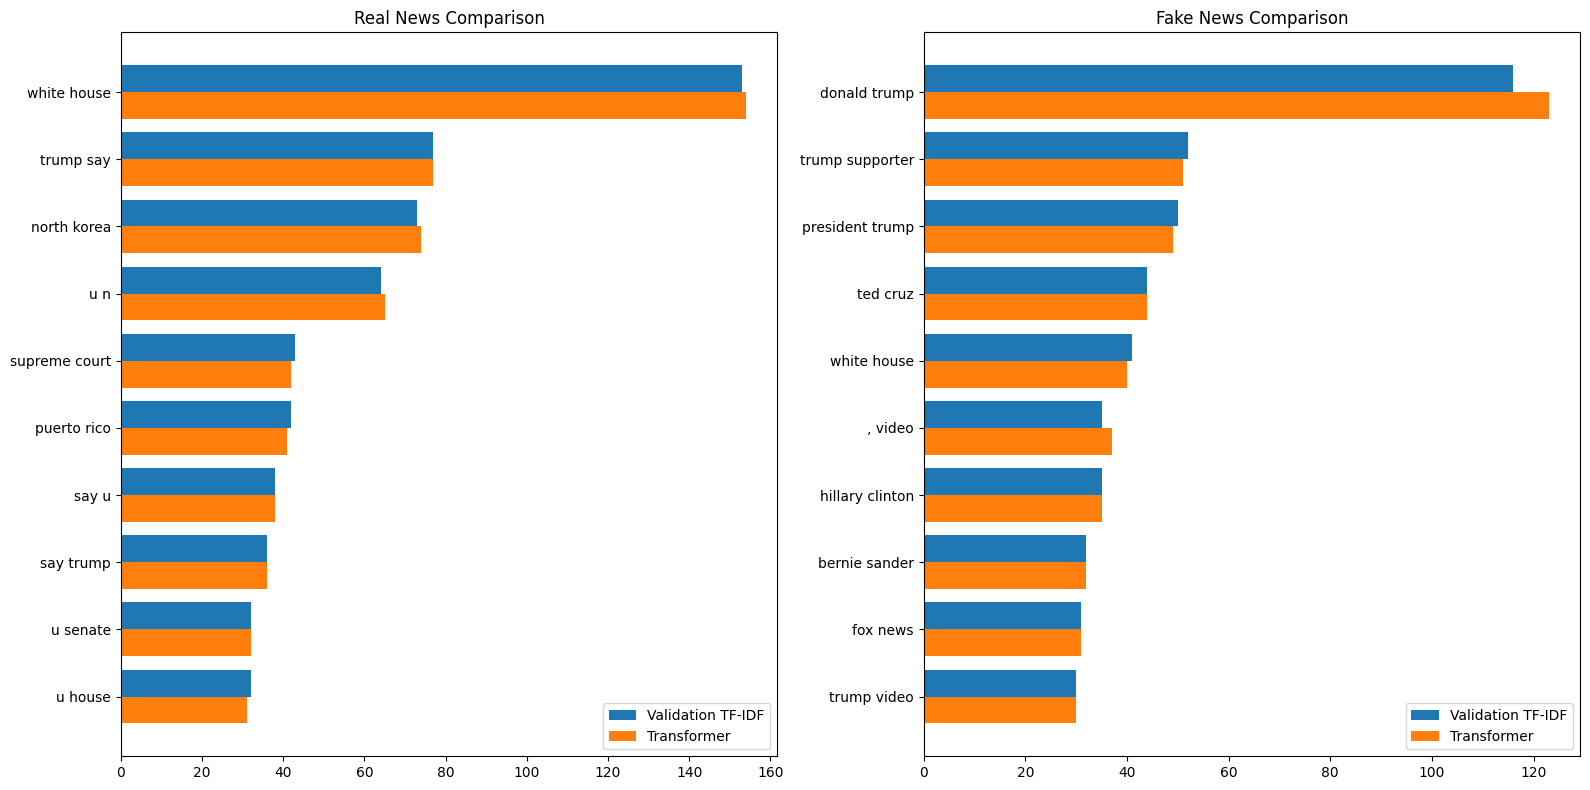

In [80]:

real_df = pd.DataFrame({
    "word": real_bilabels_val2,
    "validation": real_bicounts_val2,
    "transformer": real_bicounts_val
})

# merge duplicates safely
real_df = real_df.groupby("word", as_index=False).sum()
real_df = real_df.sort_values(
    "transformer",
    ascending=False
)
y = np.arange(len(real_df))
height = 0.4

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ---- REAL NEWS ----
axes[0].barh(
    y - height/2,
    real_df["validation"],
    height=height,
    label="Validation"
)

axes[0].barh(
    y + height/2,
    real_df["transformer"],
    height=height,
    label="Transformer"
)

axes[0].set_yticks(y)
axes[0].set_yticklabels(real_df["word"])
axes[0].invert_yaxis()
axes[0].set_title("Real News Comparison")
axes[0].legend()

# -------- FAKE NEWS --------

fake_df = pd.DataFrame({
    "word": fake_bilabels_val2,
    "validation": fake_bicounts_val2,
    "transformer": fake_bicounts_val
})

fake_df = fake_df.groupby("word", as_index=False).sum()
fake_df = fake_df.sort_values(
    "transformer",
    ascending=False
)
y2 = np.arange(len(fake_df))

axes[1].barh(
    y2 - height/2,
    fake_df["validation"],
    height=height,
    label="Validation"
)

axes[1].barh(
    y2 + height/2,
    fake_df["transformer"],
    height=height,
    label="Transformer"
)

axes[1].set_yticks(y2)
axes[1].set_yticklabels(fake_df["word"])
axes[1].invert_yaxis()
axes[1].set_title("Fake News Comparison")
axes[1].legend()

plt.tight_layout()
plt.show()

## Final remarks

1. The plots show that it is important to keep bigrams for the analysis, this is clearly seen in the bar plots, based on the frequency of words and how things like "white house" or "fox news" might loose meaning if separated.
2. BoW baseline model performed well but it was ourperformed by the variants of TF-IDF.
3. Grid searh helped to improve the model only slightly, which means that the model already performs well, and there might be additional aspects to perform in the data.
4. Sentence transformers like BGE and Qwen3 performed similarly to the base models. Using semantics might be more useful in long texts than in headlines.
5. Every other model was outperformed by fine tuning a pre model. This was faster than iterating nto arrive to the best conditions.  

Areas to improve:
1. keep apostrophes in data cleaning
2. tune min_df and other features of the vectorizers.




In [ ]:

Final_models = [

{   "User":"Laxmi", "model": "TinyBert", "accuracy": 0.967,
    "User":"Nicole", "model": "RoBerta-Fake News", "accuracy": 0.966,
    "User":"Alan", "model": "DistilBert", "accuracy": 0.963,
     }

]

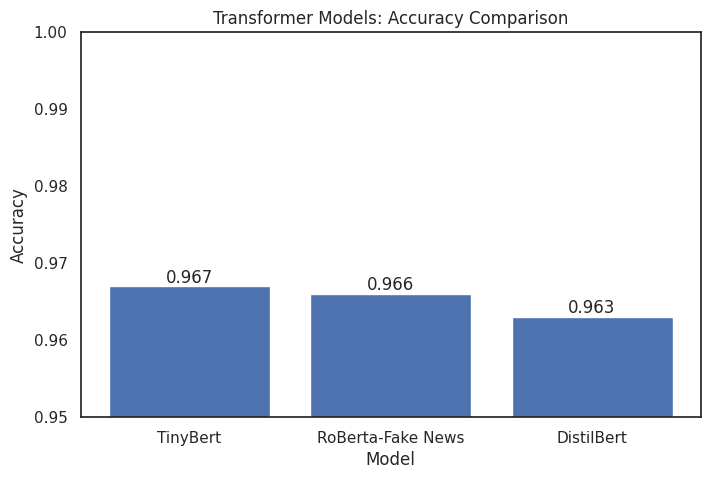

In [85]:
import matplotlib.pyplot as plt
sns.set(style="white")
# Original data
Final_models = [
    {"User": "Laxmi", "model": "TinyBert", "accuracy": 0.967},
    {"User": "Nicole", "model": "RoBerta-Fake News", "accuracy": 0.966},
    {"User": "Alan", "model": "DistilBert", "accuracy": 0.963},
]

# Extract values
models = [item["model"] for item in Final_models]
accuracies = [item["accuracy"] for item in Final_models]

# Create bar plot
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)

# Labels and title
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Transformer Models: Accuracy Comparison")

# Optional: set y-axis limits for better visualization
plt.ylim(0.95, 1.0)

# Show values on top of bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.0005, f"{acc:.3f}", ha='center')

plt.show()

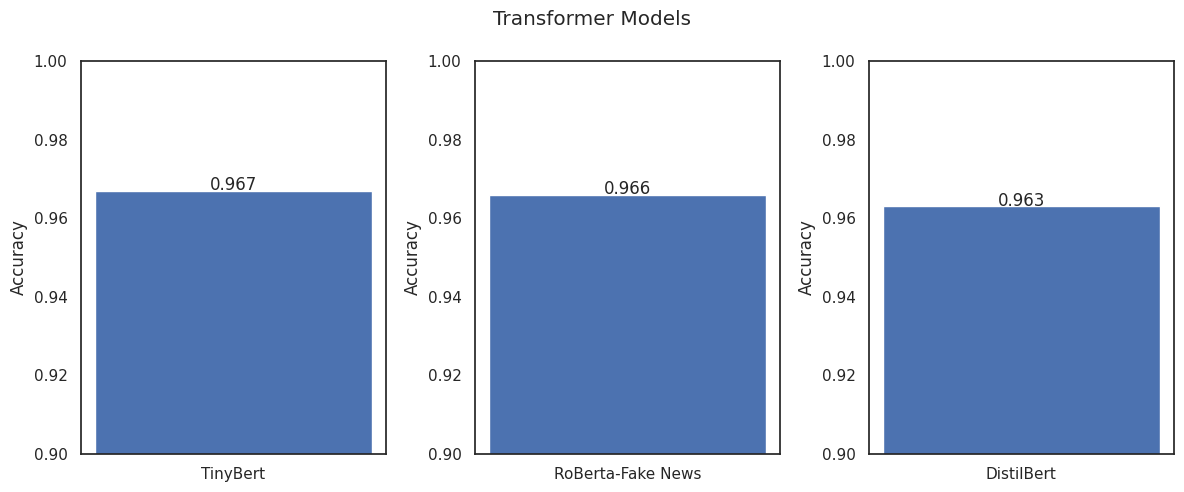

In [90]:
import matplotlib.pyplot as plt

# Data
Final_models = [
    {"User": "Laxmi", "model": "TinyBert", "accuracy": 0.967},
    {"User": "Nicole", "model": "RoBerta-Fake News", "accuracy": 0.966},
    {"User": "Alan", "model": "DistilBert", "accuracy": 0.963},
]

# Create separate subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for ax, item in zip(axes, Final_models):
    ax.bar(item["model"], item["accuracy"])

    # Individual y-axis scaling
    ax.set_ylim(0.90,1)

    # Labels
    #ax.set_title(item["model"])
    ax.set_ylabel("Accuracy")

    # Show value on top
    ax.text(
        0,
        item["accuracy"] + 0.0002,
        f'{item["accuracy"]:.3f}',
        ha='center'
    )

plt.suptitle("Transformer Models")
plt.tight_layout()
plt.show()